# **4. Análisis de Promociones y Descuentos**

## **4.1 Panorama general de promociones**

In [5]:
from pathlib import Path
import pandas as pd

def find_project_root(start: Path, marker: str = "data", max_up: int = 6) -> Path:
    p = start.resolve()
    for _ in range(max_up):
        if (p / marker).exists():
            return p
        p = p.parent
    return start.resolve()

ROOT = find_project_root(Path.cwd())
DATA_PROCESSED = ROOT / "data" / "processed"

ts_path = DATA_PROCESSED / "ts_ventas_dia_tienda_producto.csv"

df_ts = pd.read_csv(ts_path, parse_dates=["FECHA"])

print("Shape:", df_ts.shape)
df_ts.head()

promo_summary = {
    "Total registros": len(df_ts),
    "Registros con promoción": int(df_ts["PROMO_FLAG_AGG"].sum()) if "PROMO_FLAG_AGG" in df_ts.columns else None,
    "Porcentaje con promoción": (
        df_ts["PROMO_FLAG_AGG"].mean() * 100
        if "PROMO_FLAG_AGG" in df_ts.columns else None
    ),
    "Descuento total": df_ts["DESCUENTO"].sum(),
    "Descuento promedio (%)": (
        (df_ts["DESCUENTO"] / df_ts["VENTA_BRUTA"]).mean() * 100
        if "VENTA_BRUTA" in df_ts.columns else None
    )
}

promo_summary

Shape: (228, 15)


{'Total registros': 228,
 'Registros con promoción': 24,
 'Porcentaje con promoción': np.float64(10.526315789473683),
 'Descuento total': np.float64(85309.0),
 'Descuento promedio (%)': np.float64(1.333619883416488)}

## Interpretación del Análisis de Promociones

La muestra analizada contiene 228 registros agregados a nivel Día–Tienda–Producto. De estos, 24 registros presentan actividad promocional, lo que representa aproximadamente el 10.53% del total.

### Intensidad promocional

Un 10.53% de productos en promoción indica una estrategia promocional selectiva y no masiva en la fecha analizada. Esto sugiere que la política comercial no estuvo orientada a una campaña generalizada, sino a intervenciones puntuales sobre productos específicos.

Desde el punto de vista analítico, esta proporción es relevante porque:

- Permite evaluar el efecto diferencial de promociones.
- Genera contraste entre productos con y sin incentivo comercial.
- Introduce variabilidad estructural útil para modelado predictivo.

### Impacto económico de los descuentos

El descuento total registrado asciende a 85.309, lo que representa aproximadamente 1.33% del total de ventas brutas.

Este nivel agregado de descuento es relativamente bajo, lo que indica que:

- No se trató de una jornada de alta presión promocional.
- El impacto financiero directo de descuentos fue moderado.
- La mayoría de los ingresos provino de ventas sin incentivo directo.

### Implicaciones estratégicas

Aunque el porcentaje de promociones es reducido, su análisis es crítico para el proyecto de predicción de ventas, ya que:

1. Las promociones introducen discontinuidades en el comportamiento de demanda.
2. Pueden generar picos artificiales que el modelo debe aprender a distinguir.
3. Influyen tanto en volumen como en ingreso neto.


### Relevancia para Modelado

La presencia de promociones en el dataset es un elemento clave para modelos de Deep Learning. Variables como PROMO_FLAG_AGG o DESCUENTO_PCT pueden actuar como features exógenas, mejorando la capacidad del modelo para capturar cambios estructurales en la demanda.


## **4.2 Frecuencia de promociones por producto y tienda**

In [6]:
promo_producto = (
    df_ts.groupby("PLU_SAP")["PROMO_FLAG_AGG"]
    .mean()
    .sort_values(ascending=False)
)

promo_producto.head(10)

PLU_SAP
27     1.0
41     1.0
98     1.0
73     1.0
126    1.0
189    1.0
181    1.0
124    1.0
133    1.0
383    1.0
Name: PROMO_FLAG_AGG, dtype: float64

## Interpretación – Frecuencia de promociones por producto

El análisis calcula la media de la variable `PROMO_FLAG_AGG` por producto (PLU_SAP). Dado que esta variable es binaria (0 = sin promoción, 1 = con promoción), su promedio puede interpretarse como la proporción de veces que un producto estuvo en promoción dentro del período analizado.

En el resultado observado, varios productos presentan un valor de 1.0, lo que indica que estuvieron en promoción en el 100% de las observaciones disponibles para ese producto en esta muestra.

### Lectura estratégica

Que un producto tenga frecuencia promocional igual a 1.0 puede significar:

- Fue vendido únicamente bajo esquema promocional en el período analizado.
- Hace parte de una categoría permanentemente incentivada.
- Se trata de una muestra temporal limitada donde coincidió con una campaña específica.

Este patrón es relevante porque una alta frecuencia promocional puede:

- Distorsionar la percepción de su demanda real.
- Generar dependencia comercial del incentivo.
- Aumentar la volatilidad en ventas si la promoción se retira.

### Implicaciones para modelado predictivo

Desde la perspectiva de Deep Learning y forecasting:

1. Productos con frecuencia promocional alta requieren tratamiento especial.
2. El modelo debe aprender el efecto estructural de la promoción.
3. Puede ser necesario incluir variables como:
   - Días consecutivos en promoción.
   - Intensidad del descuento.
   - Historial promocional acumulado.

Si no se modela correctamente, el algoritmo podría:
- Sobreestimar ventas futuras cuando no haya promoción.
- Confundir ventas estructurales con ventas inducidas.



## **4.3 Impacto de promoción en ventas netas**

In [7]:
impacto_promo = (
    df_ts.groupby("PROMO_FLAG_AGG")["VENTA_NETA"]
    .mean()
)

impacto_promo

PROMO_FLAG_AGG
0    24861.960784
1    22908.000000
Name: VENTA_NETA, dtype: float64

## Interpretación – Impacto de promoción en ventas netas

El análisis compara el promedio de `VENTA_NETA` entre registros con promoción (`PROMO_FLAG_AGG = 1`) y sin promoción (`PROMO_FLAG_AGG = 0`).

Resultados observados:

- Sin promoción (0): 24.861,96
- Con promoción (1): 22.908,00

### Lectura inicial

Contrario a lo que podría esperarse, en esta muestra el promedio de ventas netas es ligeramente menor cuando existe promoción.

Esto puede interpretarse de varias maneras:

1. El descuento reduce el ingreso neto por observación.
2. Las promociones están aplicándose sobre productos de menor precio.
3. La muestra corresponde a un único día o periodo corto, lo que limita la representatividad.
4. El efecto volumen (más unidades vendidas) no compensa totalmente el menor precio.

Es importante recordar que aquí estamos analizando ingreso neto promedio por registro agregado, no margen ni volumen total.

### Consideraciones técnicas

El análisis actual evalúa promedio simple, pero no controla por:

- Tipo de producto.
- Precio base.
- Categoría.
- Nivel de tienda.
- Elasticidad por segmento.

Por lo tanto, el resultado no debe interpretarse como que "las promociones no funcionan", sino como una evidencia preliminar que requiere análisis más profundo.

### Implicaciones estratégicas

Desde una perspectiva gerencial, este hallazgo abre preguntas clave:

- ¿Las promociones están orientadas a productos de baja rotación?
- ¿Se está priorizando volumen sobre ingreso?
- ¿Existe canibalización entre productos?
- ¿Las promociones están diseñadas para atraer tráfico más que para maximizar ticket?

### Relevancia para el modelo predictivo

Para modelos de Deep Learning, este resultado es especialmente valioso porque indica que el efecto promocional no es lineal ni necesariamente positivo en ingresos netos.

El modelo deberá:

- Aprender efectos heterogéneos por producto.
- Capturar interacción entre precio, promoción y volumen.
- Diferenciar entre impacto en unidades y en ingreso.



## **4.4 Comparación ventas con promoción vs sin promoción**

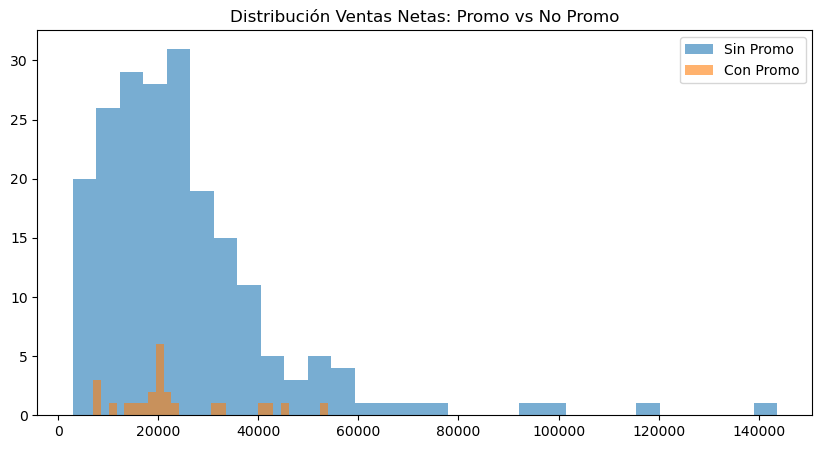

In [8]:
import matplotlib.pyplot as plt

ventas_promo = df_ts[df_ts["PROMO_FLAG_AGG"] == 1]["VENTA_NETA"]
ventas_no_promo = df_ts[df_ts["PROMO_FLAG_AGG"] == 0]["VENTA_NETA"]

plt.figure(figsize=(10,5))
plt.hist(ventas_no_promo, bins=30, alpha=0.6, label="Sin Promo")
plt.hist(ventas_promo, bins=30, alpha=0.6, label="Con Promo")
plt.legend()
plt.title("Distribución Ventas Netas: Promo vs No Promo")
plt.show()

## **4.5 Elasticidad aproximada precio–ventas (exploratorio)**

In [10]:
# Proxy de precio medio
df_ts["PRECIO_MEDIO_APROX"] = df_ts["VENTA_NETA"] / df_ts["UNIDADES"]

correlacion = df_ts[["PRECIO_MEDIO_APROX", "VENTA_NETA"]].corr()

correlacion

,PRECIO_MEDIO_APROX,VENTA_NETA
PRECIO_MEDIO_APROX,1.000000,0.196395
VENTA_NETA,0.196395,1.000000


## Interpretación – Elasticidad aproximada precio–ventas (análisis exploratorio)

En este análisis se construye un proxy de precio medio como:

PRECIO_MEDIO_APROX = VENTA_NETA / UNIDADES

Posteriormente se calcula la correlación entre este precio aproximado y las ventas netas agregadas.

Resultado observado:

Correlación (PRECIO_MEDIO_APROX vs VENTA_NETA) ≈ 0.196

### Lectura técnica

La correlación es positiva pero débil (≈ 0.19). Esto indica que, en esta muestra:

- No existe una relación inversa fuerte entre precio y ventas netas.
- Los productos con mayor precio promedio tienden ligeramente a generar mayores ingresos netos.
- No se observa evidencia preliminar de elasticidad negativa marcada en ingresos.

Sin embargo, es fundamental aclarar que aquí se está correlacionando precio con ingreso neto, no con unidades vendidas. Esto introduce un efecto mecánico: productos más costosos pueden generar mayores ingresos aunque vendan menos unidades.

### Limitaciones del análisis actual

Este cálculo no representa una elasticidad económica formal, ya que:

1. No se trabaja en logaritmos.
2. No se controla por producto.
3. No se controla por efectos de promoción.
4. No se analiza variación temporal.
5. No se separa el efecto precio del efecto volumen.

Por lo tanto, el resultado debe interpretarse como un diagnóstico preliminar y no como una medida estructural de sensibilidad al precio.

### Implicaciones estratégicas

Desde una perspectiva comercial, este resultado sugiere que:

- El ingreso total no depende fuertemente de pequeñas variaciones en precio dentro de esta muestra.
- Podría existir segmentación por tipo de producto donde la elasticidad varíe significativamente.
- Las decisiones de pricing deberían analizarse a nivel producto o categoría, no de forma agregada.

### Relevancia para el modelo de Deep Learning

Para el modelo predictivo, este hallazgo es relevante porque indica que:

- El precio es una variable informativa, aunque no dominante.
- Es probable que la interacción entre precio y promoción sea más importante que el precio aislado.
- Variables derivadas como descuento porcentual o precio relativo frente al histórico podrían tener mayor poder predictivo.
